**DATA LOADER**

In [1]:
import pandas as pd

class DataLoader:

    def __init__(self, file_path):
        self.file_path = file_path

    def load_data(self):
        return pd.read_csv(self.file_path)

**EDA**

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

class EDAAnalyzer:

    def __init__(self, df):
        self.df = df

    def class_distribution(self):
        plt.figure(figsize=(6,4))
        sns.countplot(x='Class', data=self.df)
        plt.show()

    def amount_distribution(self):
        plt.figure(figsize=(10,5))
        sns.histplot(self.df['Amount'], bins=50)
        plt.show()

    def fraud_vs_nonfraud(self):
        plt.figure(figsize=(8,5))
        sns.boxplot(x='Class', y='Amount', data=self.df)
        plt.show()

    def correlation_heatmap(self):
        plt.figure(figsize=(14,10))
        sns.heatmap(self.df.corr(), cmap='coolwarm')
        plt.show()

**PREPROCESSING**

In [3]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

class Preprocessor:

    def split_data(self, X, y):

        return train_test_split(
            X,
            y,
            test_size=0.2,
            stratify=y,
            random_state=42
        )

    def apply_smote(self, x_train, y_train):

        smote = SMOTE(random_state=42)

        return smote.fit_resample(
            x_train,
            y_train
        )

**TRAINING**

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import joblib
import os

class FraudModelTrainer:

    def train_logistic(self, X, y):

        model = LogisticRegression()

        model.fit(X, y)

        return model

    def train_random_forest(self, X, y):

        model = RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )

        model.fit(X, y)

        return model

    def train_xgboost(self, X, y):

        model = XGBClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )

        model.fit(X, y)

        return model

    def save_artifacts(
        self,
        model,
        threshold,
        path
    ):

        os.makedirs(
        os.path.dirname(path),
        exist_ok=True
        )

        artifacts = {
            "model": model,
            "threshold": threshold
        }

        joblib.dump(
            artifacts,
            path
        )

        print(f"Saved at {path}")

**EVALUATOR**

In [5]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

class ModelEvaluator:

    def evaluate(self, model, X_test, y_test, threshold=0.5):

        y_prob = model.predict_proba(X_test)[:,1]

        y_pred = (y_prob > threshold).astype(int)

        print(classification_report(y_test, y_pred))

        print(confusion_matrix(y_test, y_pred))

        print(
            "ROC AUC:",
            roc_auc_score(y_test, y_prob)
        )

**SHAP**

In [6]:
import shap

class ShapAnalyzer:

    def __init__(self, model):
        self.model = model

    def summary_plot(self, X):

        explainer = shap.TreeExplainer(
            self.model
        )

        shap_values = explainer.shap_values(X)

        shap.summary_plot(
            shap_values,
            X
        )

    def bar_plot(self, X):

        explainer = shap.TreeExplainer(
            self.model
        )

        shap_values = explainer.shap_values(X)

        shap.summary_plot(
            shap_values,
            X,
            plot_type='bar'
        )

**MAIN**

Saved at models/fraud_system.pkl
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.84      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

[[56852    12]
 [   16    82]]
ROC AUC: 0.9831145633548862


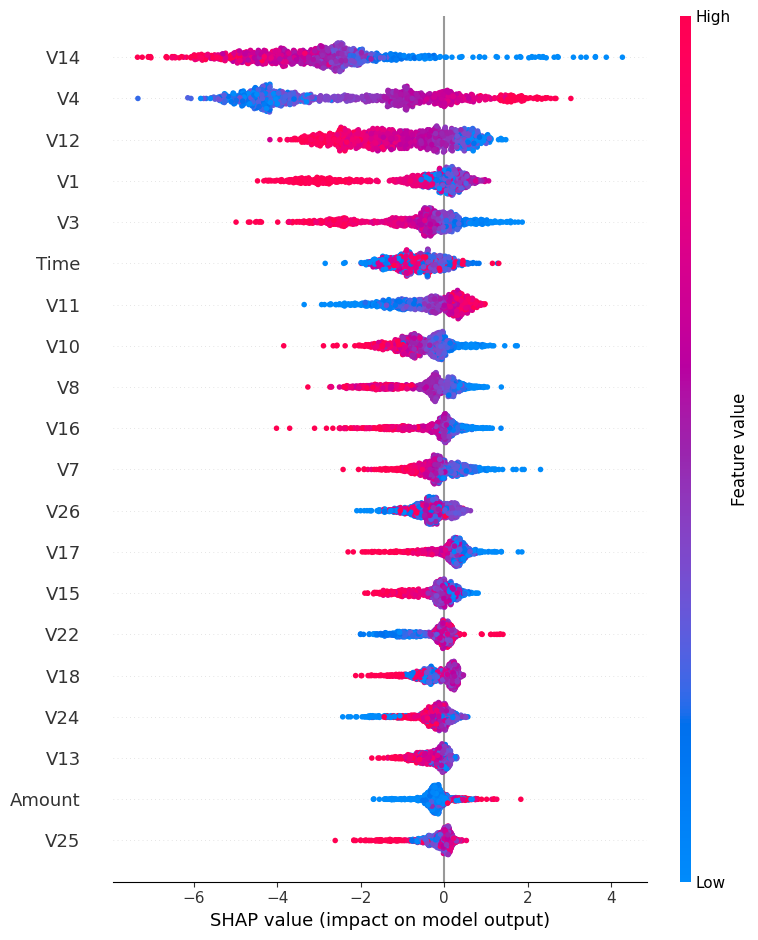

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)
import shap

# Assuming all class definitions (DataLoader, Preprocessor, etc.) are in previous cells
# and have been executed.

# Load
loader = DataLoader("creditcard.csv")
df = loader.load_data()

# Split
X = df.drop("Class", axis=1)
y = df["Class"]

preprocessor = Preprocessor()

x_train, x_test, y_train, y_test = (
    preprocessor.split_data(X, y)
)

x_train_resampled, y_train_resampled = (
    preprocessor.apply_smote(
        x_train,
        y_train
    )
)

# Train
trainer = FraudModelTrainer()

xgb_model = trainer.train_xgboost(
    x_train_resampled,
    y_train_resampled
)

trainer.save_artifacts(
    model=xgb_model,
    threshold=0.9,
    path="models/fraud_system.pkl"
)

# Evaluate
evaluator = ModelEvaluator()

evaluator.evaluate(
    xgb_model,
    x_test,
    y_test,
    threshold=0.9
)

# SHAP
shap_analyzer = ShapAnalyzer(
    xgb_model
)

shap_analyzer.summary_plot(
    x_test.sample(1000, random_state=42) # Added random_state for reproducibility
)

In [9]:
import shap
import matplotlib.pyplot as plt

# SHAP values
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(x_test)

# Create plot
shap.summary_plot(
    shap_values,
    x_test,
    show=False
)

# Save image
plt.savefig(
    "shap_summary.png",
    bbox_inches="tight",
    dpi=300
)

plt.close()